In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r"C:\Users\javier.sdiaz\Proyecto ML_2025\data\processed\serie_temporal_procesada.csv", sep=",")

df


,Fecha_Hora,Temp_amb,Dir_viento,Vel_viento,Energia,Potencia,Oil_Temp,cosPhi,Frecuencia,Temp_int,Q,Rad_prom,HeatsinkTemp_prom,Idc_total,V_total
0,2022-01-01 00:00:00,11.346512,222.558422,2.611367,26.931747,0.0,26.079072,0.0,49.960499,20.329768,0.0,0.0,17.075259,0.0,1146.307697
1,2022-01-01 00:15:00,11.300000,223.087589,2.582713,0.000000,0.0,25.479083,0.0,49.959999,20.179770,0.0,0.0,16.883596,0.0,1147.522942
2,2022-01-01 00:30:00,11.306667,224.893609,2.640629,0.000000,0.0,24.879095,0.0,49.959999,20.029773,0.0,0.0,16.691933,0.0,1150.385870
3,2022-01-01 00:45:00,11.293333,223.534547,2.808005,0.000000,0.0,24.279182,0.0,49.959999,19.879776,0.0,0.0,16.506316,0.0,1153.091744
4,2022-01-01 01:00:00,11.259853,230.927235,3.147298,0.000000,0.0,23.745968,0.0,49.960503,19.741495,0.0,0.0,16.404334,0.0,1150.639247
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
105211,2024-12-31 22:45:00,4.145149,223.663976,5.285611,740.750000,0.0,8.529718,0.0,50.000000,10.085310,0.0,0.0,7.151938,0.0,1145.415732
105212,2024-12-31 23:00:00,4.245148,219.700928,5.490529,740.750000,0.0,8.329723,0.0,50.000000,10.117952,0.0,0.0,7.165451,0.0,1145.233798
105213,2024-12-31 23:15:00,4.376957,222.824833,5.048825,740.750000,0.0,8.329723,0.0,50.000000,10.117952,0.0,0.0,7.165451,0.0,1145.233798
105214,2024-12-31 23:30:00,4.493333,220.484426,4.876356,740.750000,0.0,8.329723,0.0,50.000000,10.117952,0.0,0.0,7.165451,0.0,1145.233798


In [3]:
# Convertir Fecha_Hora a datetime y establecerla como índice
df["Fecha_Hora"] = pd.to_datetime(df["Fecha_Hora"])
df.set_index("Fecha_Hora", inplace=True)

In [4]:
# Seleccionar solo columnas numéricas
df_numeric = df.select_dtypes(include=['float64', 'int64'])

# Escalar datos
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_numeric)

# Convertir de nuevo a DataFrame con el índice original
df_scaled = pd.DataFrame(X_scaled, columns=df_numeric.columns, index=df_numeric.index)

# Mostrar el resultado
df_scaled.head()

,Temp_amb,Dir_viento,Vel_viento,Energia,Potencia,Oil_Temp,cosPhi,Frecuencia,Temp_int,Q,Rad_prom,HeatsinkTemp_prom,Idc_total,V_total
Fecha_Hora,,,,,,,,,,,,,,
2022-01-01 00:00:00,-0.144556,0.379367,-0.345880,-0.726158,-0.596844,-0.465090,-0.958731,0.081745,-0.121464,-0.409921,-0.602483,-0.394136,-0.599486,0.073892
2022-01-01 00:15:00,-0.150734,0.385464,-0.360192,-0.733037,-0.596844,-0.497848,-0.958731,0.081632,-0.140002,-0.409921,-0.602483,-0.409102,-0.599486,0.085759
2022-01-01 00:30:00,-0.149848,0.406273,-0.331265,-0.733037,-0.596844,-0.530606,-0.958731,0.081632,-0.158539,-0.409921,-0.602483,-0.424067,-0.599486,0.113717
2022-01-01 00:45:00,-0.151619,0.390614,-0.247670,-0.733037,-0.596844,-0.563359,-0.958731,0.081632,-0.177076,-0.409921,-0.602483,-0.438560,-0.599486,0.140141
2022-01-01 01:00:00,-0.156066,0.475792,-0.078211,-0.733037,-0.596844,-0.592471,-0.958731,0.081745,-0.194165,-0.409921,-0.602483,-0.446523,-0.599486,0.116191


In [25]:
from sklearn.cluster import KMeans

# Definir el número de clusters
n_clusters = 9
kmeans = KMeans(n_clusters=n_clusters, random_state=42)

# Ajustar y predecir clusters
df_scaled["cluster"] = kmeans.fit_predict(df_scaled)

# Mostrar los primeros resultados
df_scaled.head()



,Temp_amb,Dir_viento,Vel_viento,Energia,Potencia,Oil_Temp,cosPhi,Frecuencia,Temp_int,Q,Rad_prom,HeatsinkTemp_prom,Idc_total,V_total,cluster
Fecha_Hora,,,,,,,,,,,,,,,
2022-01-01 00:00:00,-0.144556,0.379367,-0.345880,-0.726158,-0.596844,-0.465090,-0.958731,0.081745,-0.121464,-0.409921,-0.602483,-0.394136,-0.599486,0.073892,1
2022-01-01 00:15:00,-0.150734,0.385464,-0.360192,-0.733037,-0.596844,-0.497848,-0.958731,0.081632,-0.140002,-0.409921,-0.602483,-0.409102,-0.599486,0.085759,1
2022-01-01 00:30:00,-0.149848,0.406273,-0.331265,-0.733037,-0.596844,-0.530606,-0.958731,0.081632,-0.158539,-0.409921,-0.602483,-0.424067,-0.599486,0.113717,1
2022-01-01 00:45:00,-0.151619,0.390614,-0.247670,-0.733037,-0.596844,-0.563359,-0.958731,0.081632,-0.177076,-0.409921,-0.602483,-0.438560,-0.599486,0.140141,1
2022-01-01 01:00:00,-0.156066,0.475792,-0.078211,-0.733037,-0.596844,-0.592471,-0.958731,0.081745,-0.194165,-0.409921,-0.602483,-0.446523,-0.599486,0.116191,1


### METODO DEL CODO

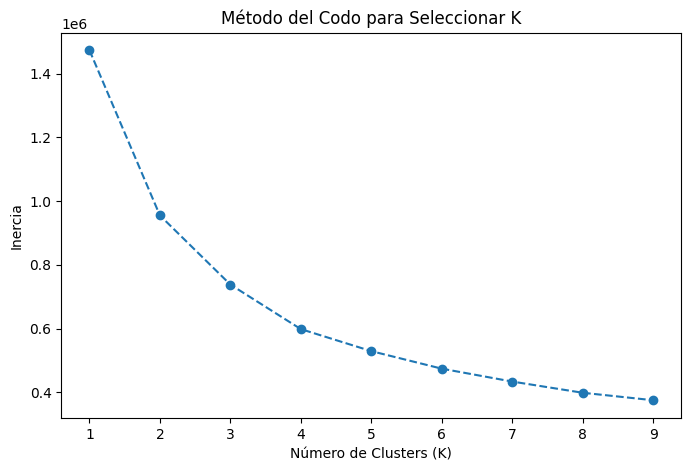

In [21]:
import matplotlib.pyplot as plt
import numpy as np

inertia = []
K_range = range(1, 10)  # Probar de 1 a 10 clusters

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df_scaled.drop(columns=["cluster"], errors="ignore"))  # Evitar columna cluster
    inertia.append(kmeans.inertia_)

# Graficar la curva del codo
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker="o", linestyle="--")
plt.xlabel("Número de Clusters (K)")
plt.ylabel("Inercia")
plt.title("Método del Codo para Seleccionar K")
plt.show()



# PASO 1 Visualizar la serie temporal

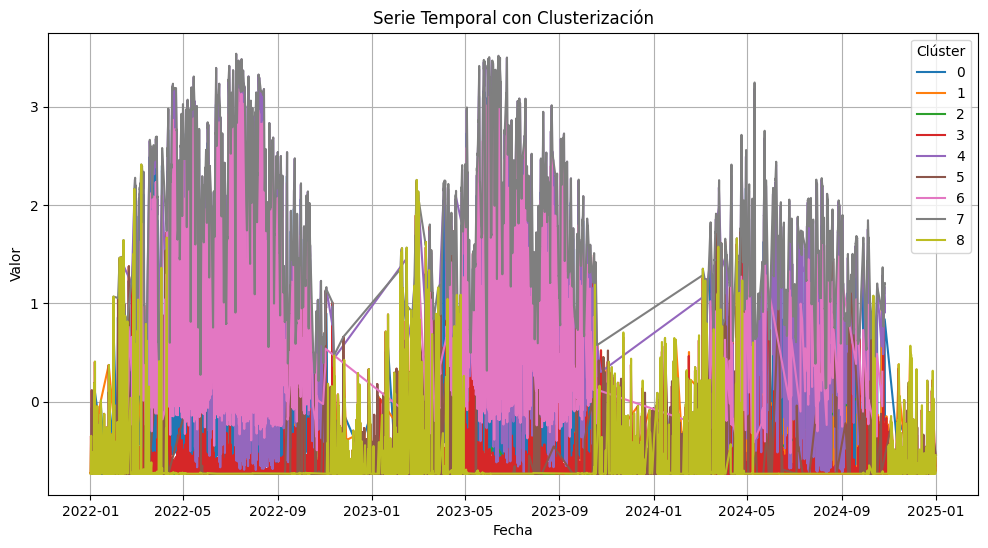

In [26]:
# Crear la figura
plt.figure(figsize=(12, 6))

# Graficar cada clúster con un color diferente
sns.lineplot(data=df_scaled, x='Fecha_Hora', y='Energia', hue='cluster', palette='tab10')

# Personalización del gráfico
plt.title('Serie Temporal con Clusterización')
plt.xlabel('Fecha')
plt.ylabel('Valor')
plt.legend(title='Clúster')
plt.grid(True)

# Mostrar el gráfico
plt.show()

In [12]:
# Gráfico de la serie temporal
#plt.figure(figsize=(12,6))
#plt.plot(df.index, df_scaled["Energia"], label="Energía", color="green")
#plt.xlabel("Fecha")
#plt.ylabel("Energía")
#plt.title("Evolución de la Energía en el tiempo")
#plt.legend()
#plt.show()

# PASO 2 Prueba de estacionariedad

En un analisis de serie temporal, es crucial determinar si la serie es estacionaria o no estacionaria. Una serie es estacionaria si sus propiedas estadísticas, como la media, la varianza y la autocovarianza, son constantes en el tiempo. Esto significa que las características de la serie no dependen del momento temporal en el que se observe la serie.

Para determinar si una serie es estacionaria, se va utilizar la prueba de Dickey-Fuller aumentada (ADF), que verifica si la raíz unitaria está presente en la serie. La hipótesis nula de esta prueba establece que la serie tiene una raíz unitaria, lo que indica que la serie es no estacionaria.

In [29]:
from statsmodels.tsa.stattools import adfuller

# Prueba de Dickey-Fuller
result = adfuller(df_scaled["Energia"])
print("Valor p:", result[1])

if result[1] < 0.05:
    print("La serie es estacionaria.")
else:
    print("La serie NO es estacionaria. Puede requerir diferenciación.")


Valor p: 0.0
La serie es estacionaria.


La función adfuller se utiliza para realizar esta prueba y devuelve varios resultados, siendo el valor p uno de los mas importantes. El valor p indica la probabilidad de obtener un valor de la estadística de prueba tan extremo como el observado, bajo la hipótesis nula de que la serie tiene una raíz unitaria (es decir, no es estacionaria).
- Si el valor p es menor que 0.05, se rechaza la hipótesis nula y se concluye que la serie es estacionaria.
- si el valor p es mayor que 0.05, no se rechaza la hipótesis nula, lo que sugiere que la serie no es estacionaria.


# PASO 3 Creación de variables adicionales

In [ ]:
# Crear retardos (lags)
#df["Energia_lag1"] = df["Energia"].shift(1)
#df["Energia_lag2"] = df["Energia"].shift(2)

# Medias móviles
#df["Energia_rolling"] = df["Energia"].rolling(window=7).mean()

# Eliminar valores nulos generados por los lags
#df = df.dropna()


# PASO 4  División en train y test

In [11]:
# Separar las características (X) y la variable objetivo (y)
X = df_scaled.drop(columns=['Energia'])  # Suponiendo que 'Energia' es la columna objetivo
y = df_scaled['Energia']

# Separar el conjunto de entrenamiento (2022 y 2023)
X_train = X[(X.index.year == 2022) | (X.index.year == 2023)]
y_train = y[(y.index.year == 2022) | (y.index.year == 2023)]

# Separar el conjunto de validación (2024)
X_val = X[X.index.year == 2024]
y_val = y[y.index.year == 2024]

# PASO 5 Entrenar un modelo simple (Regresión lineal)

In [12]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Inicializamos el modelo de Regresión Lineal
model_lr = LinearRegression()

# Entrenamos el modelo con los datos de entrenamiento
model_lr.fit(X_train, y_train)

# Hacemos predicciones en el conjunto de validación
y_val_pred_lr = model_lr.predict(X_val)

# Evaluamos el modelo con diferentes métricas
mse_lr = mean_squared_error(y_val, y_val_pred_lr)
r2_lr = model_lr.score(X_val, y_val)
mae_lr = mean_absolute_error(y_val, y_val_pred_lr)
rmse_lr = np.sqrt(mse_lr)  # Calcular RMSE como la raíz cuadrada de MSE


# Imprimimos los resultados
print(f"Error cuadrático medio (MSE) en validación (Regresión Lineal): {mse_lr}")
print(f"R² en validación (Regresión Lineal): {r2_lr}")
print(f"Error Absoluto Medio (MAE) en validación (Regresión Lineal): {mae_lr}")
print(f"Raíz del Error Cuadrático Medio (RMSE) en validación (Regresión Lineal): {rmse_lr}")









Error cuadrático medio (MSE) en validación (Regresión Lineal): 0.4377066076670863
R² en validación (Regresión Lineal): 0.2441806619995167
Error Absoluto Medio (MAE) en validación (Regresión Lineal): 0.4963791966663051
Raíz del Error Cuadrático Medio (RMSE) en validación (Regresión Lineal): 0.6615939900475868


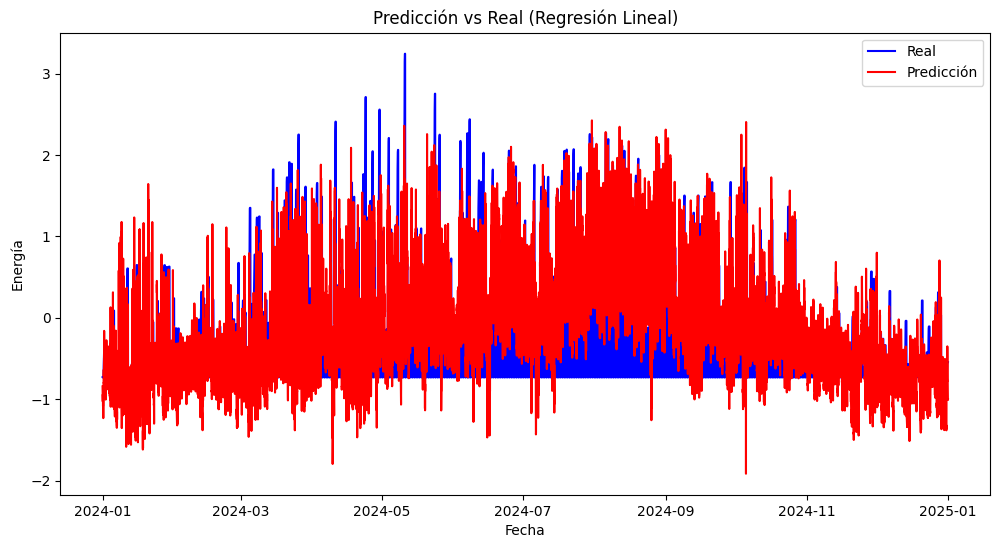

In [13]:
# Realizamos las predicciones con el modelo de regresión lineal (usamos X_test)
y_pred = model_lr.predict(X_val)

# Graficamos las predicciones vs los valores reales
plt.figure(figsize=(12, 6))
plt.plot(y_val.index, y_val, label="Real", color="blue")  # Valores reales
plt.plot(y_val.index, y_pred, label="Predicción", color="red")  # Predicciones
plt.xlabel("Fecha")
plt.ylabel("Energía")
plt.title("Predicción vs Real (Regresión Lineal)")
plt.legend()
plt.show()


In [14]:
# Crear características de lags: desplazamientos de la variable objetivo 'Energia'
for i in range(1, 25):  # Ejemplo: lags de 1 hora hasta 24 horas
    df_scaled[f'lag_{i}'] = df_scaled['Energia'].shift(i)

# Crear media móvil: ejemplo para 6 horas (en tu caso, cada fila es 15 minutos, por lo que 6 horas = 24 filas)
df_scaled['rolling_mean_6h'] = df_scaled['Energia'].rolling(window=24).mean()

# Crear otras características temporales (Día de la semana, mes, etc.)
df_scaled['day_of_week'] = df_scaled.index.dayofweek
df_scaled['hour'] = df_scaled.index.hour
df_scaled['month'] = df_scaled.index.month

# Eliminar filas con valores NaN generados por los lags y las medias móviles
df_scaled.dropna(inplace=True)


In [34]:
# Separa las características (X) y la variable objetivo (y)
X = df_scaled.drop(columns=['Energia'])
y = df_scaled['Energia']

# Dividir en entrenamiento (2022 y 2023) y validación (2024)
X_train = X[X.index.year != 2024]
y_train = y[y.index.year != 2024]
X_val = X[X.index.year == 2024]
y_val = y[y.index.year == 2024]


In [35]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

# Inicializamos el modelo de Random Forest
model_rf = RandomForestRegressor(n_estimators=100, random_state=42)

# Entrenamos el modelo
model_rf.fit(X_train, y_train)

# Hacemos predicciones
y_val_pred_rf = model_rf.predict(X_val)

# Evaluamos el modelo
mse_rf = mean_squared_error(y_val, y_val_pred_rf)
print(f"Error cuadrático medio (MSE) en validación (Random Forest): {mse_rf}")


Error cuadrático medio (MSE) en validación (Random Forest): 0.00516071508754001


In [36]:
import xgboost as xgb
from sklearn.metrics import mean_squared_error

# Convertir los datos en matrices DMatrix (opcional pero recomendado en XGBoost)
dtrain = xgb.DMatrix(X_train, label=y_train)
dval = xgb.DMatrix(X_val, label=y_val)

# Parámetros para XGBoost
params = {
    'objective': 'reg:squarederror',  # Para regresión
    'max_depth': 6,
    'learning_rate': 0.1,
    'n_estimators': 100,
    'eval_metric': 'rmse'
}

# Entrenar el modelo XGBoost
model_xgb = xgb.train(params, dtrain, num_boost_round=100)

# Hacer predicciones
y_val_pred_xgb = model_xgb.predict(dval)

# Evaluar el modelo
mse_xgb = mean_squared_error(y_val, y_val_pred_xgb)
print(f"Error cuadrático medio (MSE) en validación (XGBoost): {mse_xgb}")


c:\Users\javier.sdiaz\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\core.py:158: UserWarning: [16:34:13] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "n_estimators" } are not used.

  warnings.warn(smsg, UserWarning)


Error cuadrático medio (MSE) en validación (XGBoost): 0.002102651906594811


# ARIMA

c:\Users\javier.sdiaz\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\javier.sdiaz\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\javier.sdiaz\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\javier.sdiaz\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has bee

                               SARIMAX Results                                
Dep. Variable:                Energia   No. Observations:                70056
Model:                 ARIMA(5, 1, 0)   Log Likelihood                2503.036
Date:                Thu, 13 Mar 2025   AIC                          -4994.073
Time:                        16:35:09   BIC                          -4939.130
Sample:                             0   HQIC                         -4977.128
                              - 70056                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0349      0.002     15.050      0.000       0.030       0.039
ar.L2          0.0196      0.006      3.197      0.001       0.008       0.032
ar.L3          0.0174      0.005      3.722      0.0

c:\Users\javier.sdiaz\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\javier.sdiaz\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


Error cuadrático medio (MSE) en validación (ARIMA): 0.5881741510766055


c:\Users\javier.sdiaz\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\javier.sdiaz\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


Error cuadrático medio (MSE) en prueba (ARIMA): 0.5881741510766055


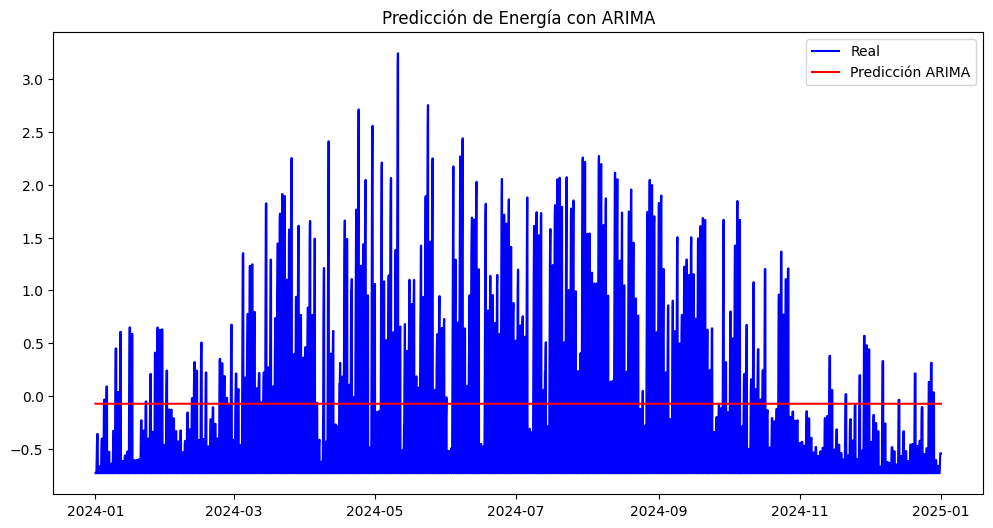

In [38]:
import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt

# Entrenamos el modelo ARIMA
# Aquí estamos utilizando (p, d, q) = (5, 1, 0) como ejemplo, puedes ajustar estos parámetros
# p: número de lags para el componente autorregresivo (AR)
# d: grado de diferenciación para hacer la serie estacionaria (I)
# q: número de lags para el componente de media móvil (MA)

model_arima = ARIMA(y_train, order=(5, 1, 0))  # Cambia los parámetros según lo que necesites
model_arima_fit = model_arima.fit()

# Resumen del modelo ARIMA
print(model_arima_fit.summary())

# Hacemos predicciones en el conjunto de validación
y_val_pred_arima = model_arima_fit.forecast(steps=len(y_val))

# Evaluamos el modelo con MSE en la validación
mse_arima = mean_squared_error(y_val, y_val_pred_arima)
print(f"Error cuadrático medio (MSE) en validación (ARIMA): {mse_arima}")

# Hacemos predicciones en el conjunto de prueba
y_test_pred_arima = model_arima_fit.forecast(steps=len(y_val))

# Evaluamos el modelo con MSE en el conjunto de prueba
mse_test_arima = mean_squared_error(y_val, y_test_pred_arima)
print(f"Error cuadrático medio (MSE) en prueba (ARIMA): {mse_test_arima}")

# Graficamos las predicciones de ARIMA vs. los valores reales
plt.figure(figsize=(12, 6))
plt.plot(y_val.index, y_val, label='Real', color='blue')
plt.plot(y_val.index, y_test_pred_arima, label='Predicción ARIMA', color='red')
plt.title('Predicción de Energía con ARIMA')
plt.legend()
plt.show();
